In [6]:
import torch

import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [7]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_SIZE': 256},  num_warps=2, num_stages=2),
        triton.Config({'BLOCK_SIZE': 256},  num_warps=4, num_stages=3),
        triton.Config({'BLOCK_SIZE': 512},  num_warps=4, num_stages=2),
        triton.Config({'BLOCK_SIZE': 512},  num_warps=4, num_stages=4),
        triton.Config({'BLOCK_SIZE': 1024}, num_warps=4, num_stages=3),
        triton.Config({'BLOCK_SIZE': 1024}, num_warps=8, num_stages=4),
        triton.Config({'BLOCK_SIZE': 2048}, num_warps=8, num_stages=3),
        triton.Config({'BLOCK_SIZE': 2048}, num_warps=8, num_stages=5),
    ],
    key=['n_elements'],
)
@triton.jit
def add_kernel(x_ptr,
               y_ptr,
               out_ptr,
               n_elements,
               BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)

    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)

    tl.store(out_ptr + offsets, x + y, mask=mask)

In [8]:
def add(x: torch.Tensor, y: torch.Tensor):
    output = torch.empty_like(x)
    n_elements = output.numel()

    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    add_kernel[grid](x, y, output, n_elements)

    return output

In [9]:
# ran on G4 GPU

torch.manual_seed(0)
size = 2**20

x = torch.rand(size, device="cuda")
y = torch.rand(size, device="cuda")

output_torch = x + y
output_triton = add(x, y)

print(output_torch)
print(output_triton)

print(torch.max(torch.abs(output_torch - output_triton)))

tensor([1.3713, 1.3076, 0.4940,  ..., 0.6460, 0.4189, 0.9635], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.6460, 0.4189, 0.9635], device='cuda:0')
tensor(0., device='cuda:0')


In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(12, 28, 1)],
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB per second',
        plot_name='vector-addition-performance',
        args={},
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)

    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

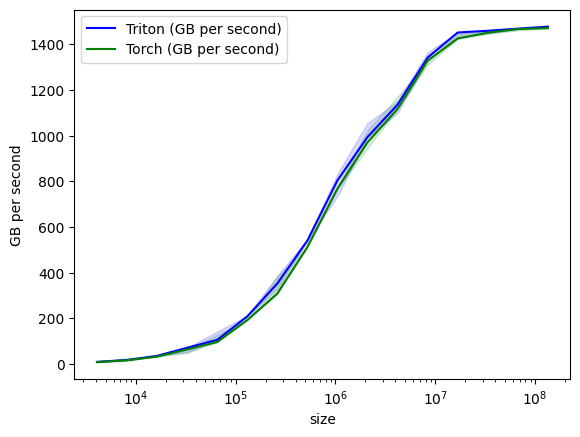

vector-addition-performance:
           size  Triton (GB per second)  Torch (GB per second)
0        4096.0                9.088757               8.000000
1        8192.0               17.504273              15.999999
2       16384.0               35.514452              31.999999
3       32768.0               71.028905              63.668394
4       65536.0              105.476395              96.000000
5      131072.0              208.271180             192.000000
6      262144.0              352.344086             308.162996
7      524288.0              540.131858             511.999982
8     1048576.0              804.122702             768.000002
9     2097152.0              994.224997             970.903706
10    4194304.0             1135.641916            1117.090900
11    8388608.0             1342.034175            1328.432375
12   16777216.0             1451.986098            1425.664225
13   33554432.0             1459.565289            1450.981565
14   67108864.0           

In [11]:
benchmark.run(print_data=True, show_plots=True)